<a href="https://colab.research.google.com/github/adhellaputria/Klasifikasi_Ekspresi_wajah/blob/main/Klasifikasi_Ekspresi_Wajah_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 😊 Klasifikasi Ekspresi Wajah
## CNN From Scratch vs Transfer Learning (MobileNetV2)

Notebook ini membangun **dua model** klasifikasi ekspresi wajah (Senang 😊, Sedih 😢, Marah 😠):

1. **CNN From Scratch** — dibangun dari awal
2. **Transfer Learning** — MobileNetV2 pretrained ImageNet

---
### ⚡ Sebelum mulai:
1. Aktifkan GPU: **Runtime → Change runtime type → T4 GPU**
2. Jalankan cell **dari atas ke bawah** secara berurutan

## 📦 Cell 1 — Install Library & Setup

In [1]:
# Install streamlit dan cloudflared untuk deployment
!pip install -q streamlit
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

import tensorflow as tf
import numpy as np
import os, time, io, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
warnings.filterwarnings('ignore')

# Cek versi TensorFlow dan GPU
print('✅ TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('✅ GPU:', gpus[0].name if gpus else '❌ Tidak ada GPU — aktifkan di Runtime!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 28.6 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.6.1) ...
Setting up cloudflared (2026.6.1) ...
Processing triggers for man-db (2.10.2-1) ...
✅ TensorFlow: 2.20.0
✅ GPU: /physical_device:GPU:0


## ⚙️ Cell 2 — Konfigurasi Global

In [2]:
# ─────────────────────────────────────────────────
# Konfigurasi — sesuaikan jika diperlukan
# ─────────────────────────────────────────────────
IMG_HEIGHT  = 224          # Tinggi gambar input (px)
IMG_WIDTH   = 224          # Lebar gambar input (px)
BATCH_SIZE  = 32           # Jumlah gambar per batch
EPOCHS_CNN  = 20           # Maksimum epoch CNN
EPOCHS_TL   = 15           # Maksimum epoch Transfer Learning
SEED        = 42
DATA_DIR    = '/content/dataset'   # Folder dataset

# Buat folder output
os.makedirs('/content/models',  exist_ok=True)
os.makedirs('/content/plots',   exist_ok=True)
os.makedirs('/content/results', exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print('✅ Konfigurasi selesai')
print(f'   IMG_SIZE  : {IMG_HEIGHT}x{IMG_WIDTH}')
print(f'   BATCH     : {BATCH_SIZE}')
print(f'   DATA_DIR  : {DATA_DIR}')

✅ Konfigurasi selesai
   IMG_SIZE  : 224x224
   BATCH     : 32
   DATA_DIR  : /content/dataset


## 📂 Cell 3 — Upload Dataset

Upload file **ZIP** dataset dengan struktur:
```
dataset.zip
├── senang/    ← ≥50 foto ekspresi senang
├── sedih/     ← ≥50 foto ekspresi sedih
└── marah/     ← ≥50 foto ekspresi marah
```
> ⚠️ Nama folder **harus huruf kecil**: `senang`, `sedih`, `marah`

In [3]:
from google.colab import files
import zipfile

# Upload file ZIP dataset
print('📤 Pilih file ZIP dataset...')
uploaded = files.upload()

# Ekstrak ZIP ke /content/
for fname in uploaded:
    if fname.endswith('.zip'):
        print(f'📦 Mengekstrak {fname}...')
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall('/content/')
        print('✅ Ekstraksi selesai!')

# Verifikasi hasil ekstraksi
print('\n📁 Isi /content/dataset/:')
!ls /content/dataset/

📤 Pilih file ZIP dataset...


Saving FOTO DATASET EKSPRESI WAJAH.zip to FOTO DATASET EKSPRESI WAJAH.zip
📦 Mengekstrak FOTO DATASET EKSPRESI WAJAH.zip...
✅ Ekstraksi selesai!

📁 Isi /content/dataset/:
ls: cannot access '/content/dataset/': No such file or directory


## 🔍 Cell 4 — Verifikasi Dataset

📋 Kelas ditemukan : ['MARAH', 'SEDIH', 'SENANG']
📋 Jumlah kelas    : 3

   ✅ [MARAH     ]: 100 gambar
   ✅ [SEDIH     ]: 100 gambar
   ✅ [SENANG    ]: 100 gambar

   Total: 300 gambar


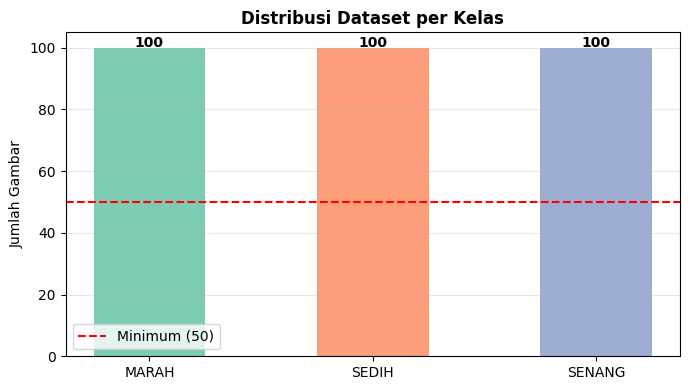

In [6]:
# ─────────────────────────────────────────────────
# Deteksi otomatis nama kelas dari nama folder
# ─────────────────────────────────────────────────
# Fix: Update DATA_DIR to the actual extracted folder name.
DATA_DIR = '/content/FOTO DATASET EKSPRESI WAJAH'

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
NUM_CLASSES = len(CLASS_NAMES)

print(f'📋 Kelas ditemukan : {CLASS_NAMES}')
print(f'📋 Jumlah kelas    : {NUM_CLASSES}')
print()

# Hitung gambar per kelas
VALID_EXT = ('.jpg','.jpeg','.png','.JPG','.JPEG','.PNG')
total = 0
counts = {}
for kls in CLASS_NAMES:
    folder = os.path.join(DATA_DIR, kls)
    imgs   = [f for f in os.listdir(folder) if f.endswith(VALID_EXT)]
    counts[kls] = len(imgs)
    total += len(imgs)
    status = '✅' if len(imgs) >= 50 else '⚠️ KURANG'
    print(f'   {status} [{kls:10s}]: {len(imgs)} gambar')

print(f'\n   Total: {total} gambar')

# Grafik distribusi
fig, ax = plt.subplots(figsize=(7,4))
colors = plt.cm.Set2(range(NUM_CLASSES))
bars   = ax.bar(counts.keys(), counts.values(), color=colors, alpha=0.85, width=0.5)
ax.axhline(y=50, color='red', linestyle='--', label='Minimum (50)')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(v), ha='center', fontweight='bold')
ax.set_title('Distribusi Dataset per Kelas', fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plots/distribusi.png', dpi=120)
plt.show()

## 🔄 Cell 5 — Load Dataset dengan `image_dataset_from_directory`

In [7]:
# ─────────────────────────────────────────────────
# Load data menggunakan tf.keras.utils.image_dataset_from_directory
# Otomatis split 80% train / 20% validasi
# ─────────────────────────────────────────────────

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

print(f'\n✅ Dataset berhasil dimuat')
print(f'   Kelas   : {CLASS_NAMES}')
print(f'   Train   : {len(train_ds)} batch × {BATCH_SIZE} = ~{len(train_ds)*BATCH_SIZE} gambar')
print(f'   Validasi: {len(val_ds)} batch')

Found 300 files belonging to 3 classes.
Using 240 files for training.
Found 300 files belonging to 3 classes.
Using 60 files for validation.

✅ Dataset berhasil dimuat
   Kelas   : ['MARAH', 'SEDIH', 'SENANG']
   Train   : 8 batch × 32 = ~256 gambar
   Validasi: 2 batch


## 🔄 Cell 6 — Augmentasi & Preprocessing

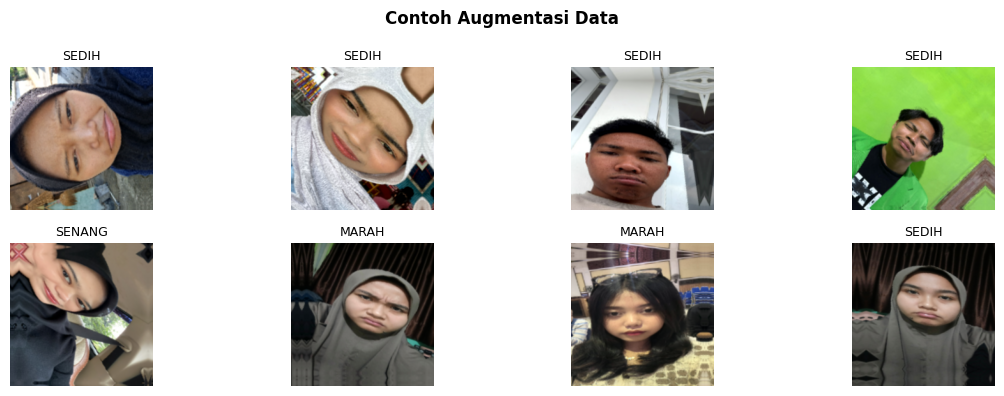

✅ Pipeline data siap


In [8]:
# ─────────────────────────────────────────────────
# Augmentasi: variasi data latih agar model tidak overfit
# Preprocessing CNN  : normalisasi piksel ke [0,1]
# Preprocessing TL   : mobilenet_v2.preprocess_input → [-1, 1]
# ─────────────────────────────────────────────────

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),          # Flip horizontal
    tf.keras.layers.RandomRotation(0.15),              # Rotasi ±15°
    tf.keras.layers.RandomZoom(0.15),                  # Zoom ±15%
    tf.keras.layers.RandomContrast(0.15),              # Variasi kontras
    tf.keras.layers.RandomTranslation(0.1, 0.1),       # Geser posisi
], name='augmentation')

preprocess_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input

# ── Pipeline untuk CNN (normalisasi ke [0,1]) ──
def prepare_cnn_train(ds):
    ds = ds.map(lambda x,y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: (x/255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

def prepare_cnn_val(ds):
    ds = ds.map(lambda x,y: (x/255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

# ── Pipeline untuk Transfer Learning (preprocess_input MobileNetV2) ──
def prepare_tl_train(ds):
    ds = ds.map(lambda x,y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: (preprocess_mobilenet(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

def prepare_tl_val(ds):
    ds = ds.map(lambda x,y: (preprocess_mobilenet(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

# Siapkan kedua versi dataset
train_cnn = prepare_cnn_train(train_ds)
val_cnn   = prepare_cnn_val(val_ds)
train_tl  = prepare_tl_train(train_ds)
val_tl    = prepare_tl_val(val_ds)

# ── Tampilkan contoh augmentasi ──
plt.figure(figsize=(12,4))
plt.suptitle('Contoh Augmentasi Data', fontweight='bold')
for images, labels in train_ds.take(1):
    for i in range(8):
        aug_img = data_augmentation(tf.expand_dims(images[i],0), training=True)[0].numpy()
        aug_img = np.clip(aug_img/255.0, 0, 1)
        ax = plt.subplot(2, 4, i+1)
        ax.imshow(aug_img)
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig('/content/plots/augmentasi.png', dpi=100)
plt.show()
print('✅ Pipeline data siap')

## 🧠 Cell 7 — Bangun Model CNN From Scratch

In [10]:
# ─────────────────────────────────────────────────
# Arsitektur CNN dari nol (from scratch)
# 3 blok Conv → MaxPool → BatchNorm → Dropout
# 2 Fully Connected layer
# ─────────────────────────────────────────────────

def build_cnn():
    model = tf.keras.Sequential([
        # Input
        tf.keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # ── Blok 1: fitur dasar (tepi, tekstur) ──
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.20), # Mengurangi dropout

        # ── Blok 2: fitur menengah (mata, mulut) ──
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.20), # Mengurangi dropout

        # ── Blok 3: fitur kompleks (pola ekspresi) ──
        tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25), # Mengurangi dropout

        # ── Classifier head ──
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.40), # Mengurangi dropout
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.30), # Mengurangi dropout

        # ── Output: probabilitas per kelas ──
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_FromScratch')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()
print(f'\n✅ CNN siap. Parameter: {cnn_model.count_params():,}')


Model: "CNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,013,475 (99.23 MB)

 Trainable params: 26,012,067 (99.23 MB)

 Non-trainable params: 1,408 (5.50 KB)


✅ CNN siap. Parameter: 26,013,475


In [11]:
# ─────────────────────────────────────────────────
# Arsitektur CNN dari nol (from scratch)
# 3 blok Conv → MaxPool → BatchNorm → Dropout
# 2 Fully Connected layer
# ─────────────────────────────────────────────────

def build_cnn():
    model = tf.keras.Sequential([
        # Input
        tf.keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # ── Blok 1: fitur dasar (tepi, tekstur) ──
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.20), # Mengurangi dropout

        # ── Blok 2: fitur menengah (mata, mulut) ──
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.20), # Mengurangi dropout

        # ── Blok 3: fitur kompleks (pola ekspresi) ──
        tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25), # Mengurangi dropout

        # ── Classifier head ──
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.40), # Mengurangi dropout
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.30), # Mengurangi dropout

        # ── Output: probabilitas per kelas ──
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_FromScratch')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()
print(f'\n✅ CNN siap. Parameter: {cnn_model.count_params():,}')

Model: "CNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,013,475 (99.23 MB)

 Trainable params: 26,012,067 (99.23 MB)

 Non-trainable params: 1,408 (5.50 KB)


✅ CNN siap. Parameter: 26,013,475


## 🚀 Cell 8 — Training CNN From Scratch

In [12]:
# ─────────────────────────────────────────────────
# Training CNN dengan callbacks:
# - EarlyStopping : hentikan jika val_accuracy tidak naik
# - ReduceLROnPlateau : turunkan LR jika stagnan
# - ModelCheckpoint  : simpan model terbaik
# ─────────────────────────────────────────────────

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/models/cnn_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

print('🚀 Training CNN From Scratch...')
print('='*50)

cnn_start = time.time()
cnn_history = cnn_model.fit(
    train_cnn,
    validation_data=val_cnn,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
    verbose=1
)
cnn_time = time.time() - cnn_start

print(f'\n✅ CNN selesai dalam {cnn_time:.1f}s ({cnn_time/60:.1f} menit)')
print(f'   Best val_accuracy : {max(cnn_history.history["val_accuracy"])*100:.2f}%')

🚀 Training CNN From Scratch...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.3208 - loss: 1.5447 - val_accuracy: 0.3500 - val_loss: 1.1359 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5417 - loss: 1.0612 - val_accuracy: 0.2667 - val_loss: 1.4053 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6000 - loss: 0.9754 - val_accuracy: 0.3000 - val_loss: 1.7434 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6208 - loss: 0.9033 - val_accuracy: 0.3000 - val_loss: 1.5818 - learning_rate: 0.0010
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7238 - loss: 0.8030
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.7542 - loss: 0.7083 - val_accuracy: 0.3000 - val_loss: 1.3423 - learning_rate: 0.0010
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.7375 - l

## 🤖 Cell 9 — Bangun Model Transfer Learning (MobileNetV2)

In [13]:
# ─────────────────────────────────────────────────
# Transfer Learning: MobileNetV2 pretrained ImageNet
# Sama persis gaya notebook contoh dosen, ditambah
# fine-tuning layer akhir untuk akurasi lebih tinggi
# ─────────────────────────────────────────────────

IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# Load base model MobileNetV2 (tanpa top layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Bekukan base model (feature extraction dulu)
base_model.trainable = False

# Tambah classifier head
tl_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
], name='TransferLearning_MobileNetV2')

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tl_model.summary()
print(f'\n✅ TL Model siap. Trainable params: {sum(tf.size(v).numpy() for v in tl_model.trainable_variables):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ TL Model siap. Trainable params: 328,707


## 🚀 Cell 10 — Training Transfer Learning (2 Tahap)

In [14]:
# ─────────────────────────────────────────────────
# Tahap 1: Feature Extraction — hanya head yang dilatih
# Tahap 2: Fine-tuning — buka 30 layer terakhir MobileNetV2
# ─────────────────────────────────────────────────

print('📌 Tahap 1: Feature Extraction (base model frozen)...')
print('='*50)

tl_start = time.time()

tl_callbacks_1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    )
]

hist1 = tl_model.fit(
    train_tl, validation_data=val_tl,
    epochs=10, callbacks=tl_callbacks_1, verbose=1
)

# ── Tahap 2: Fine-tuning ──
print('\n📌 Tahap 2: Fine-tuning (30 layer terakhir dibuka)...')
print('='*50)

base_model.trainable = True
# Bekukan layer awal, buka layer akhir saja
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Gunakan LR sangat kecil agar tidak merusak bobot pretrained
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tl_callbacks_2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-8, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/models/tl_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

hist2 = tl_model.fit(
    train_tl, validation_data=val_tl,
    epochs=EPOCHS_TL, callbacks=tl_callbacks_2, verbose=1
)

tl_time = time.time() - tl_start

# Gabungkan history 2 tahap
tl_combined = {}
for k in hist1.history:
    tl_combined[k] = hist1.history[k] + hist2.history[k]

print(f'\n✅ TL selesai dalam {tl_time:.1f}s ({tl_time/60:.1f} menit)')
print(f'   Best val_accuracy : {max(tl_combined["val_accuracy"])*100:.2f}%')

📌 Tahap 1: Feature Extraction (base model frozen)...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 65s 4s/step - accuracy: 0.3792 - loss: 1.6838 - val_accuracy: 0.2667 - val_loss: 1.3663
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3708 - loss: 1.3933 - val_accuracy: 0.3333 - val_loss: 1.2338
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5250 - loss: 1.0301 - val_accuracy: 0.3500 - val_loss: 1.1480
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5667 - loss: 0.9088 - val_accuracy: 0.4333 - val_loss: 1.1001
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6833 - loss: 0.7624 - val_accuracy: 0.3000 - val_loss: 1.1307
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7417 - loss: 0.6717 - val_accuracy: 0.4000 - val_loss: 1.1097
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7542 - loss: 0.6420 - val_accuracy: 0.4500 - val_loss: 1.0796
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8042 - los

## 📈 Cell 11 — Grafik Training History

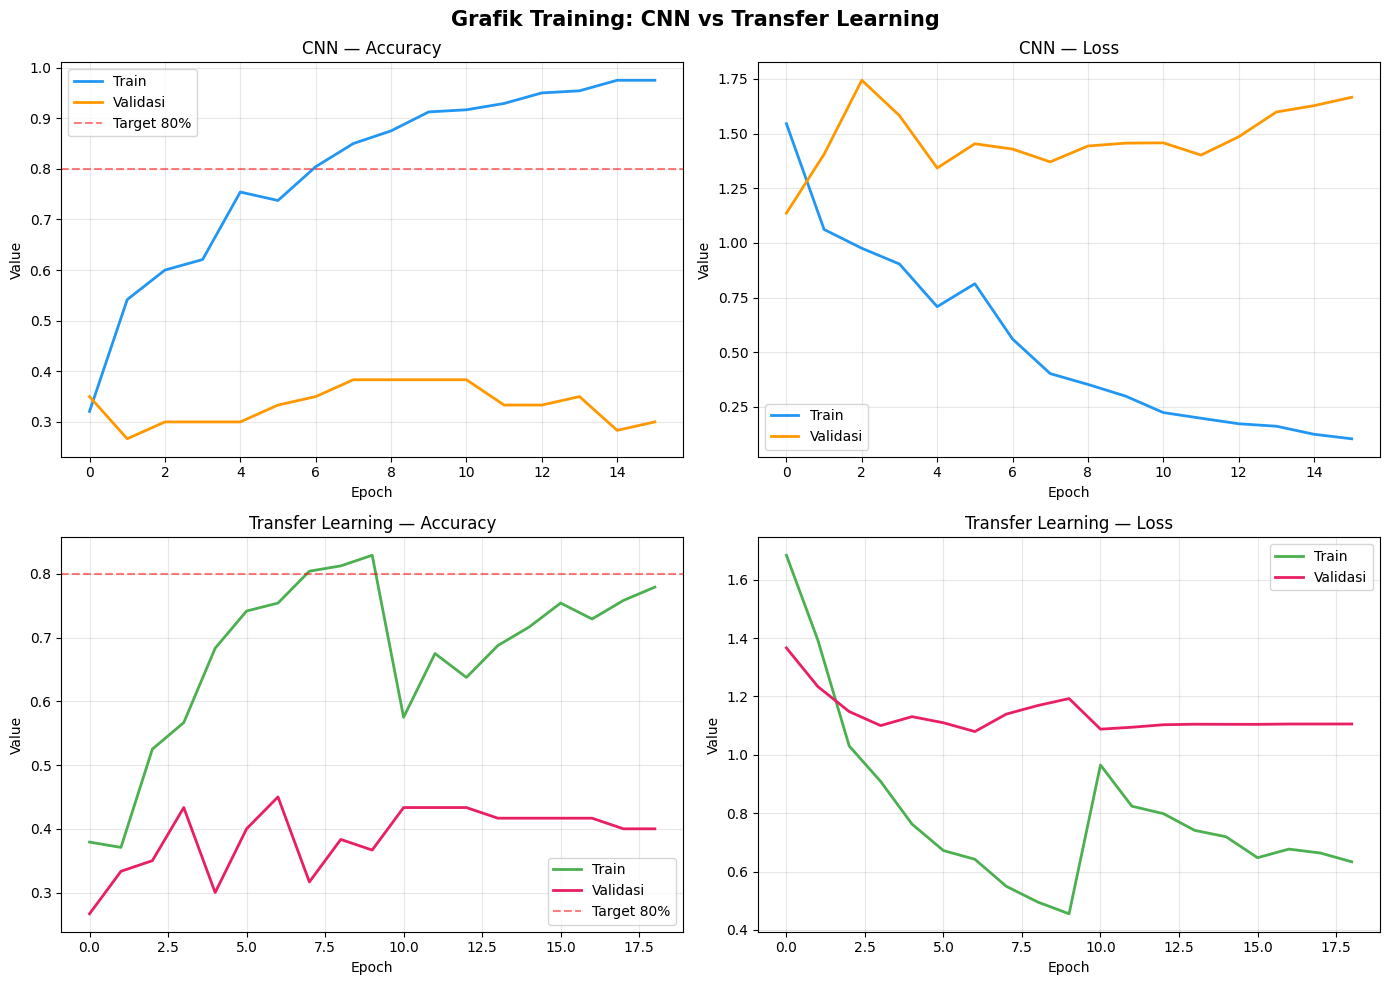

✅ Grafik disimpan: /content/plots/training_history.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Grafik Training: CNN vs Transfer Learning',
             fontsize=15, fontweight='bold')

# CNN Accuracy
axes[0,0].plot(cnn_history.history['accuracy'],     label='Train',   color='#2196F3', lw=2)
axes[0,0].plot(cnn_history.history['val_accuracy'], label='Validasi',color='#FF9800', lw=2)
axes[0,0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target 80%')
axes[0,0].set_title('CNN — Accuracy'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# CNN Loss
axes[0,1].plot(cnn_history.history['loss'],     label='Train',   color='#2196F3', lw=2)
axes[0,1].plot(cnn_history.history['val_loss'], label='Validasi',color='#FF9800', lw=2)
axes[0,1].set_title('CNN — Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# TL Accuracy
axes[1,0].plot(tl_combined['accuracy'],     label='Train',   color='#4CAF50', lw=2)
axes[1,0].plot(tl_combined['val_accuracy'], label='Validasi',color='#E91E63', lw=2)
axes[1,0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target 80%')
axes[1,0].set_title('Transfer Learning — Accuracy'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# TL Loss
axes[1,1].plot(tl_combined['loss'],     label='Train',   color='#4CAF50', lw=2)
axes[1,1].plot(tl_combined['val_loss'], label='Validasi',color='#E91E63', lw=2)
axes[1,1].set_title('Transfer Learning — Loss'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('/content/plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: /content/plots/training_history.png')

## 📊 Cell 12 — Evaluasi Kedua Model

In [16]:
# ─────────────────────────────────────────────────
# Kumpulkan prediksi dari validation set
# lalu hitung metrik: Accuracy, Precision, Recall, F1
# ─────────────────────────────────────────────────

def evaluate_model(model, val_pipeline, name):
    y_true, y_pred = [], []
    for x_batch, y_batch in val_pipeline:
        preds = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(y_batch.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f'\n{"="*45}')
    print(f'📊 Evaluasi: {name}')
    print(f'{"="*45}')
    print(f'   Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'   Precision : {prec:.4f}')
    print(f'   Recall    : {rec:.4f}')
    print(f'   F1-Score  : {f1:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES)}')

    return {'accuracy':acc,'precision':prec,'recall':rec,
            'f1_score':f1,'confusion_matrix':cm}

cnn_results = evaluate_model(cnn_model, val_cnn, 'CNN From Scratch')
tl_results  = evaluate_model(tl_model,  val_tl,  'Transfer Learning (MobileNetV2)')


📊 Evaluasi: CNN From Scratch
   Accuracy  : 0.3833 (38.33%)
   Precision : 0.2368
   Recall    : 0.3833
   F1-Score  : 0.2885

              precision    recall  f1-score   support

       MARAH       0.41      0.80      0.54        20
       SEDIH       0.00      0.00      0.00        22
      SENANG       0.33      0.39      0.36        18

    accuracy                           0.38        60
   macro avg       0.25      0.40      0.30        60
weighted avg       0.24      0.38      0.29        60


📊 Evaluasi: Transfer Learning (MobileNetV2)
   Accuracy  : 0.4333 (43.33%)
   Precision : 0.4479
   Recall    : 0.4333
   F1-Score  : 0.4178

              precision    recall  f1-score   support

       MARAH       0.50      0.25      0.33        20
       SEDIH       0.43      0.41      0.42        22
      SENANG       0.41      0.67      0.51        18

    accuracy                           0.43        60
   macro avg       0.45      0.44      0.42        60
weighted avg       0.4

## 🗺️ Cell 13 — Confusion Matrix

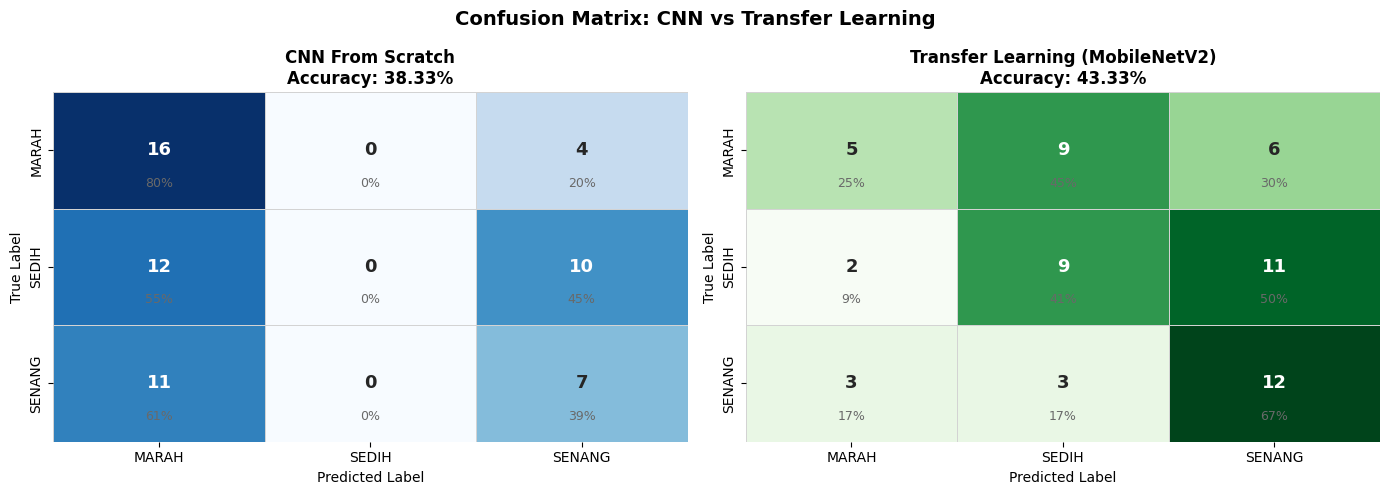

✅ Confusion matrix disimpan


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix: CNN vs Transfer Learning',
             fontsize=14, fontweight='bold')

for ax, res, title, cmap in zip(
    axes,
    [cnn_results, tl_results],
    ['CNN From Scratch', 'Transfer Learning (MobileNetV2)'],
    ['Blues', 'Greens']
):
    cm      = res['confusion_matrix']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='lightgray', cbar=False,
                annot_kws={'size':13,'weight':'bold'})

    # Tambahkan persentase di bawah angka
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j+0.5, i+0.78, f'{cm_norm[i,j]*100:.0f}%',
                    ha='center', va='center', fontsize=9, color='dimgray')

    ax.set_title(f'{title}\nAccuracy: {res["accuracy"]*100:.2f}%', fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix disimpan')

## 📋 Cell 14 — Tabel Perbandingan Performa

        Metrik CNN From Scratch Transfer Learning
      Accuracy           38.33%            43.33%
     Precision           0.2368            0.4479
        Recall           0.3833            0.4333
      F1-Score           0.2885            0.4178
Waktu Training       79.2 detik       104.8 detik


,Metrik,CNN From Scratch,Transfer Learning
0,Accuracy,38.33%,43.33%
1,Precision,0.2368,0.4479
2,Recall,0.3833,0.4333
3,F1-Score,0.2885,0.4178
4,Waktu Training,79.2 detik,104.8 detik


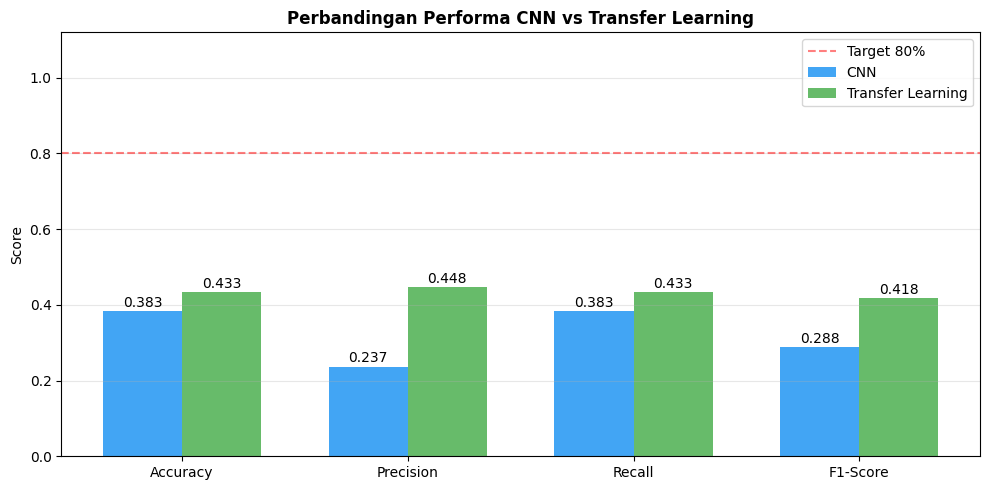

In [18]:
import pandas as pd

# ─────────────────────────────────────────────────
# Tabel perbandingan metrik kedua model
# ─────────────────────────────────────────────────
data = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Waktu Training'],
    'CNN From Scratch': [
        f"{cnn_results['accuracy']*100:.2f}%",
        f"{cnn_results['precision']:.4f}",
        f"{cnn_results['recall']:.4f}",
        f"{cnn_results['f1_score']:.4f}",
        f"{cnn_time:.1f} detik"
    ],
    'Transfer Learning': [
        f"{tl_results['accuracy']*100:.2f}%",
        f"{tl_results['precision']:.4f}",
        f"{tl_results['recall']:.4f}",
        f"{tl_results['f1_score']:.4f}",
        f"{tl_time:.1f} detik"
    ]
}
df = pd.DataFrame(data)
print(df.to_string(index=False))

from IPython.display import display
display(df.style.set_caption('Perbandingan CNN vs Transfer Learning'
                ).set_properties(**{'text-align':'center'}))

# Bar chart perbandingan
keys   = ['accuracy','precision','recall','f1_score']
labels = ['Accuracy','Precision','Recall','F1-Score']
cv     = [cnn_results[k] for k in keys]
tv     = [tl_results[k]  for k in keys]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x-w/2, cv, w, label='CNN',               color='#2196F3', alpha=0.85)
b2 = ax.bar(x+w/2, tv, w, label='Transfer Learning', color='#4CAF50', alpha=0.85)
for bar in [*b1,*b2]:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=10)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target 80%')
ax.set_ylim(0,1.12); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Perbandingan Performa CNN vs Transfer Learning', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('/content/plots/comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Cell 15 — Simpan Model

In [ ]:
# Simpan model dalam format .h5
cnn_model.save('/content/models/cnn_model.h5')
tl_model.save('/content/models/tl_model.h5')
print('✅ Model tersimpan:')
print('   /content/models/cnn_model.h5')
print('   /content/models/tl_model.h5')

# Simpan metrik ke JSON (dibutuhkan oleh app.py Streamlit)
metrics_data = {
    'cnn': {
        'accuracy' : float(cnn_results['accuracy']),
        'precision': float(cnn_results['precision']),
        'recall'   : float(cnn_results['recall']),
        'f1_score' : float(cnn_results['f1_score']),
        'train_time': float(cnn_time),
        'confusion_matrix': cnn_results['confusion_matrix'].tolist()
    },
    'tl': {
        'accuracy' : float(tl_results['accuracy']),
        'precision': float(tl_results['precision']),
        'recall'   : float(tl_results['recall']),
        'f1_score' : float(tl_results['f1_score']),
        'train_time': float(tl_time),
        'confusion_matrix': tl_results['confusion_matrix'].tolist()
    },
    'classes': CLASS_NAMES
}
with open('/content/results/metrics.json','w') as f:
    json.dump(metrics_data, f, indent=2)
print('✅ Metrik tersimpan: /content/results/metrics.json')

## 🌐 Cell 16 — Buat Aplikasi Streamlit

Cell ini menulis file `app.py` langsung dari notebook menggunakan `%%writefile`
(sama persis seperti notebook contoh dosen).

In [ ]:
%%writefile /content/app.py

import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np
import json, os, io
import matplotlib.pyplot as plt
import seaborn as sns

# ── Konfigurasi halaman ──────────────────────────────────────
st.set_page_config(
    page_title='Klasifikasi Ekspresi Wajah',
    page_icon='😊', layout='wide'
)

# ── Konstanta ────────────────────────────────────────────────
IMG_HEIGHT = 224
IMG_WIDTH  = 224
CLASS_NAMES = ['marah', 'sedih', 'senang']
EMOJI = {'senang':'😊', 'sedih':'😢', 'marah':'😠'}

# ── Load model & metrik ──────────────────────────────────────
@st.cache_resource
def load_models():
    cnn = tf.keras.models.load_model('/content/models/cnn_model.h5')
    tl  = tf.keras.models.load_model('/content/models/tl_model.h5')
    return cnn, tl

@st.cache_data
def load_metrics():
    with open('/content/results/metrics.json') as f:
        return json.load(f)

cnn_model, tl_model = load_models()
metrics = load_metrics()
preprocess_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input

# ── Header ───────────────────────────────────────────────────
st.markdown('''
<div style="background:linear-gradient(135deg,#667eea,#764ba2);
            padding:1.5rem;border-radius:12px;text-align:center;color:white;margin-bottom:1.5rem">
  <h1>😊 Klasifikasi Ekspresi Wajah 😢 😠</h1>
  <p>CNN From Scratch vs Transfer Learning (MobileNetV2)</p>
</div>''', unsafe_allow_html=True)

# ── Sidebar ───────────────────────────────────────────────────
menu = st.sidebar.radio('Menu', [
    '🏠 Beranda', '📸 Prediksi', '📊 Evaluasi', '🔬 Perbandingan'
])

# ════════════════════════════════════════════════════════════
# HALAMAN: BERANDA
# ════════════════════════════════════════════════════════════
if menu == '🏠 Beranda':
    col1, col2, col3, col4 = st.columns(4)
    col1.metric('CNN Accuracy',  f"{metrics['cnn']['accuracy']*100:.2f}%")
    col2.metric('TL Accuracy',   f"{metrics['tl']['accuracy']*100:.2f}%")
    col3.metric('CNN F1-Score',  f"{metrics['cnn']['f1_score']:.4f}")
    col4.metric('TL F1-Score',   f"{metrics['tl']['f1_score']:.4f}")

    st.markdown('---')
    st.markdown('''
    ### 📌 Tentang Proyek
    Proyek ini membandingkan **CNN From Scratch** vs **Transfer Learning (MobileNetV2)**
    untuk klasifikasi ekspresi wajah: **Senang 😊**, **Sedih 😢**, **Marah 😠**

    | Model | Keunggulan |
    |-------|-----------|
    | CNN From Scratch | Mudah dipahami, parameter sedikit |
    | Transfer Learning | Akurasi tinggi, cocok untuk dataset kecil |
    ''')

# ════════════════════════════════════════════════════════════
# HALAMAN: PREDIKSI
# ════════════════════════════════════════════════════════════
elif menu == '📸 Prediksi':
    st.header('📸 Prediksi Ekspresi Wajah')
    uploaded = st.file_uploader('Upload foto wajah (JPG/PNG)',
                                type=['jpg','jpeg','png'])

    if uploaded:
        image = Image.open(uploaded).convert('RGB')
        col_img, col_res = st.columns([1, 2])

        with col_img:
            st.image(image, caption='Gambar Input', use_container_width=True)

        with col_res:
            if st.button('🔍 Prediksi', type='primary', use_container_width=True):
                img_arr = np.array(image.resize((IMG_HEIGHT, IMG_WIDTH)),
                                   dtype=np.float32)
                img_exp = np.expand_dims(img_arr, axis=0)

                # Prediksi CNN (normalisasi /255)
                cnn_proba = cnn_model.predict(img_exp/255.0, verbose=0)[0]
                cnn_pred  = CLASS_NAMES[np.argmax(cnn_proba)]

                # Prediksi TL (preprocess_input mobilenet)
                tl_proba  = tl_model.predict(
                    preprocess_mobilenet(img_exp.copy()), verbose=0)[0]
                tl_pred   = CLASS_NAMES[np.argmax(tl_proba)]

                # Tampilkan hasil
                c1, c2 = st.columns(2)
                c1.success(f'🧠 CNN: **{cnn_pred.upper()}** {EMOJI[cnn_pred]}\n'
                           f'({max(cnn_proba)*100:.1f}%)')
                c2.success(f'🤖 TL : **{tl_pred.upper()}** {EMOJI[tl_pred]}\n'
                           f'({max(tl_proba)*100:.1f}%)')

                if cnn_pred == tl_pred:
                    st.info(f'✅ Kedua model sepakat: **{cnn_pred.upper()}** {EMOJI[cnn_pred]}')
                else:
                    st.warning('⚠️ Model tidak sepakat!')

                # Grafik probabilitas
                fig, axes = plt.subplots(1, 2, figsize=(10, 3))
                for ax, proba, title in zip(
                    axes, [cnn_proba, tl_proba],
                    ['CNN From Scratch', 'Transfer Learning']
                ):
                    colors = ['#F44336','#2196F3','#4CAF50']
                    bars = ax.barh(CLASS_NAMES, proba*100,
                                   color=colors, alpha=0.8, height=0.5)
                    for bar, v in zip(bars, proba):
                        ax.text(bar.get_width()+0.5,
                                bar.get_y()+bar.get_height()/2,
                                f'{v*100:.1f}%', va='center', fontweight='bold')
                    ax.set_xlim(0, 115); ax.set_title(title, fontweight='bold')
                    ax.grid(True, axis='x', alpha=0.3)
                    ax.spines[['top','right']].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig)

# ════════════════════════════════════════════════════════════
# HALAMAN: EVALUASI
# ════════════════════════════════════════════════════════════
elif menu == '📊 Evaluasi':
    st.header('📊 Hasil Evaluasi Model')
    tab1, tab2 = st.tabs(['🧠 CNN From Scratch', '🤖 Transfer Learning'])

    for tab, key, cmap in zip([tab1,tab2],['cnn','tl'],['Blues','Greens']):
        with tab:
            m = metrics[key]
            c1,c2,c3,c4 = st.columns(4)
            c1.metric('Accuracy',  f"{m['accuracy']*100:.2f}%")
            c2.metric('Precision', f"{m['precision']:.4f}")
            c3.metric('Recall',    f"{m['recall']:.4f}")
            c4.metric('F1-Score',  f"{m['f1_score']:.4f}")

            cm = np.array(m['confusion_matrix'])
            fig, ax = plt.subplots(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                        cbar=False, annot_kws={'weight':'bold'})
            ax.set_ylabel('True'); ax.set_xlabel('Predicted')
            ax.set_title('Confusion Matrix', fontweight='bold')
            st.pyplot(fig)

            if os.path.exists('/content/plots/training_history.png'):
                st.image('/content/plots/training_history.png',
                         caption='Grafik Training History')

# ════════════════════════════════════════════════════════════
# HALAMAN: PERBANDINGAN
# ════════════════════════════════════════════════════════════
elif menu == '🔬 Perbandingan':
    st.header('🔬 Perbandingan CNN vs Transfer Learning')

    cnn, tl = metrics['cnn'], metrics['tl']
    rows = {
        'Accuracy' : (f"{cnn['accuracy']*100:.2f}%",  f"{tl['accuracy']*100:.2f}%"),
        'Precision': (f"{cnn['precision']:.4f}",       f"{tl['precision']:.4f}"),
        'Recall'   : (f"{cnn['recall']:.4f}",          f"{tl['recall']:.4f}"),
        'F1-Score' : (f"{cnn['f1_score']:.4f}",        f"{tl['f1_score']:.4f}"),
        'Waktu Training': (f"{cnn['train_time']:.1f}s", f"{tl['train_time']:.1f}s"),
    }
    md_table = '| Metrik | CNN | Transfer Learning | Terbaik |\n|---|---|---|---|\n'
    num_keys = ['accuracy','precision','recall','f1_score']
    for label, (cv, tv) in rows.items():
        k = label.lower().replace('-','_').replace(' training','_time')
        if k in num_keys:
            winner = '✅ TL' if tl[k] > cnn[k] else '✅ CNN'
        else:
            winner = '✅ CNN' if cnn['train_time'] < tl['train_time'] else '✅ TL'
        md_table += f'| {label} | {cv} | {tv} | {winner} |\n'
    st.markdown(md_table)

    if os.path.exists('/content/plots/comparison.png'):
        st.image('/content/plots/comparison.png')

    winner_name = 'Transfer Learning' if tl['accuracy'] > cnn['accuracy'] else 'CNN'
    st.markdown(f'''
    ### 📝 Analisis

    **Model Terbaik: {winner_name}**

    - Transfer Learning unggul karena memanfaatkan fitur dari 1.4 juta gambar ImageNet
    - CNN From Scratch membutuhkan lebih banyak data untuk mencapai akurasi yang sama
    - Fine-tuning 2 tahap pada TL membantu adaptasi ke domain ekspresi wajah

    | Aspek | CNN | Transfer Learning |
    |-------|-----|-------------------|
    | Waktu training | ⚡ Lebih cepat | 🐢 2 tahap |
    | Dataset kecil | ⚠️ Rentan overfit | ✅ Lebih tahan |
    | Interpretabilitas | ✅ Mudah dipahami | ⚠️ Kompleks |
    ''')

st.markdown('---')
st.caption('😊 Klasifikasi Ekspresi Wajah | CNN vs Transfer Learning | Streamlit + TensorFlow')


## 🚀 Cell 17 — Jalankan Streamlit via Cloudflare Tunnel

Klik link yang muncul setelah tulisan:

`Your quick Tunnel has been created! Visit it at:`

> Sama persis dengan cara di notebook contoh dosen!

In [ ]:
# Jalankan Streamlit dan expose ke internet via Cloudflare tunnel
!streamlit run /content/app.py --server.port 8501 & cloudflared tunnel --url http://localhost:8501

# Jika dijalankan di laptop, cukup:
# !streamlit run app.py